In [1]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

In [2]:
DOCKING_RESULTS_REAL_2 = {}
DOCKING_RESULTS_ORIGINAL = {}

# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL_2 = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

# For each pocket - REAL 2
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL_2))):
    try:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL_2, pocket, 'report.csv'))
        DOCKING_RESULTS_REAL_2[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}
    except:
        pass

# For each pocket - ORIGINAL
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
    DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

100%|██████████| 276/276 [00:09<00:00, 29.81it/s]


In [3]:
# Define pockets and compounds
POCKETS = sorted(DOCKING_RESULTS_ORIGINAL)
COMPOUNDS = sorted(DOCKING_RESULTS_ORIGINAL[POCKETS[0]])

print(f"Number of pockets: {len(POCKETS)}")
print(f"Number of compounds: {len(COMPOUNDS)}")

scores = [DOCKING_RESULTS_ORIGINAL[pocket][compound] for pocket in POCKETS for compound in COMPOUNDS]
print(f"Average score: {round(np.average(scores), 3)}")
print(f"Percentile 25: {round(np.percentile(scores, 25), 3)}")
print(f"Percentile 5: {round(np.percentile(scores, 5), 3)}")
print(f"Percentile 1: {round(np.percentile(scores, 1), 3)}")
print(f"Percentile 0.1: {round(np.percentile(scores, 0.1), 3)}")
del scores

Number of pockets: 276
Number of compounds: 100154
Average score: -5.223
Percentile 25: -7.311
Percentile 5: -8.341
Percentile 1: -9.138
Percentile 0.1: -10.111


In [21]:
cpd_to_pockets = {}
cpd_to_proteins = {}
pocket_to_cpds = {}
protein_to_cpds = {}

SCORES = [-8, -9, -10, -11]

for SCORE in SCORES:

    cpd_to_pockets[SCORE] = {}
    cpd_to_proteins[SCORE] = {}
    pocket_to_cpds[SCORE] = defaultdict(set)
    protein_to_cpds[SCORE] = defaultdict(set)

    for compound in tqdm(COMPOUNDS):
        pockets = set([pocket for pocket in POCKETS if DOCKING_RESULTS_ORIGINAL[pocket][compound] < SCORE])
        proteins = set([pocket.split("_")[1] for pocket in pockets])
        cpd_to_pockets[SCORE][compound] = pockets
        cpd_to_proteins[SCORE][compound] = proteins
        for pocket in pockets:
            pocket_to_cpds[SCORE][pocket].add(compound)
        for protein in proteins:
            protein_to_cpds[SCORE][protein].add(compound)

100%|██████████| 100154/100154 [00:09<00:00, 11126.21it/s]


In [42]:
hits = [1] + [i for i in range(10, 100_000, 10)]
y_pockets = {}
y_proteins = {}
for score in SCORES:
    y_pockets[score] = list()
    y_proteins[score] = list()
    for N in hits:
        # print(f"Number of pockets with {N}+ hits: {len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N])}")
        y_pockets[score].append(len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N]))
        y_proteins[score].append(len([i for i in protein_to_cpds[score] if len(protein_to_cpds[score][i]) > N]))

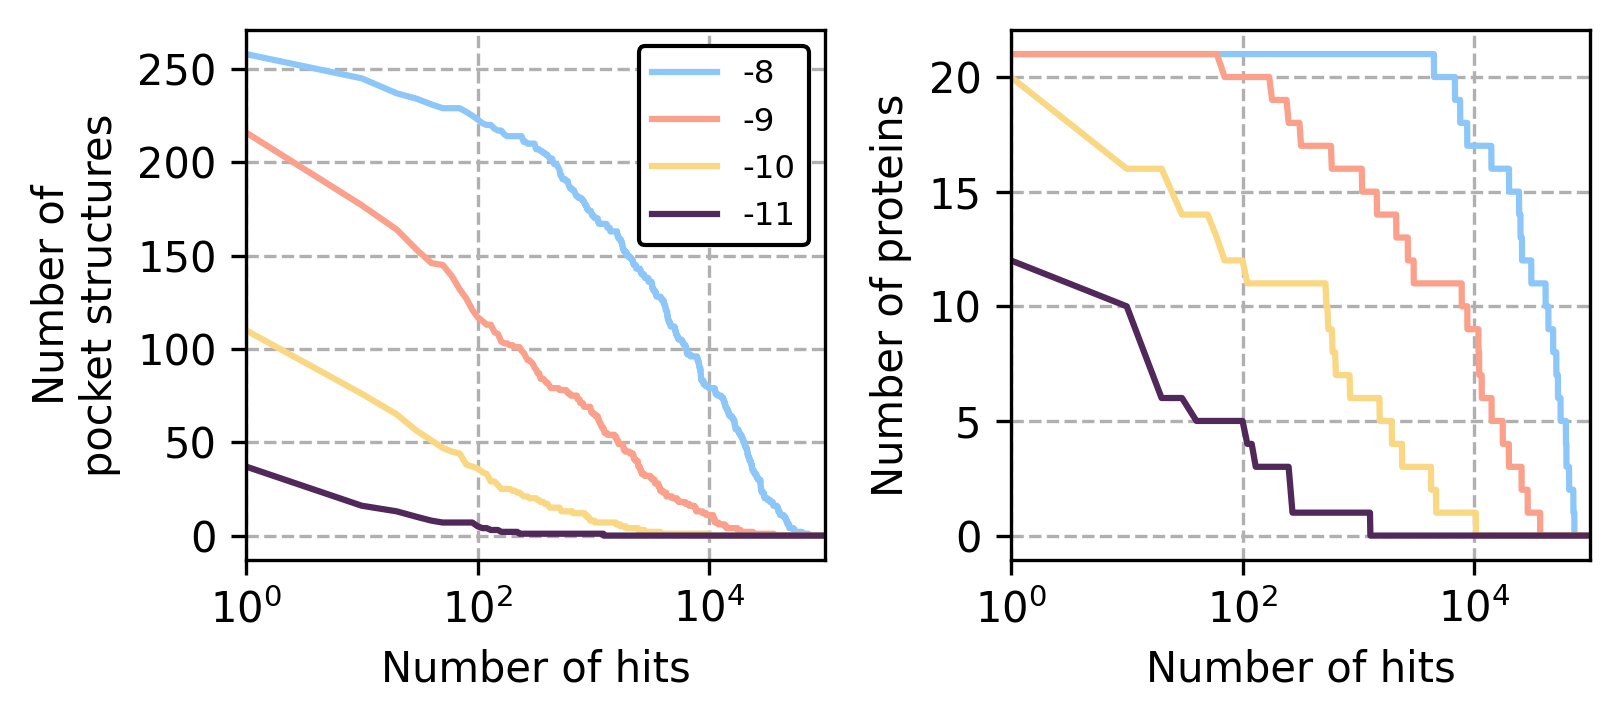

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300)

COLORS= ['#50285A', '#FAD782', '#FAA08B', '#8DC7FA'][::-1]
for score, color in zip(SCORES, COLORS):
    ax[0].plot(hits, y_pockets[score], label=str(score), c=color)
for score, color in zip(SCORES, COLORS):
    ax[1].plot(hits, y_proteins[score], label=str(score), c=color)


ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_ylabel("Number of\npocket structures")
ax[0].set_xlabel("Number of hits")
ax[0].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 7.8})
ax[0].set_xscale('log')
ax[0].set_xlim([1, 100_000])

ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_xlabel("Number of hits")
ax[1].set_ylabel("Number of proteins")
ax[1].set_xscale('log')
ax[1].set_xlim([1, 100_000])

plt.tight_layout()
plt.show()

In [52]:
POCKET_PAIRS = set([tuple(sorted([i,j])) for i in POCKETS for j in POCKETS if i != j])